# Neural Networks for Classification

The regression notebook `U1-3_Regression-5_KerasIntro` built a network that outputs a single
unbounded number. A classifier needs something different at the end: a **probability distribution
over classes**. That one change — softmax output, cross-entropy loss — is the whole difference, and
everything else about the network carries over unchanged.

Because the data is 2-D we can do what no real problem allows: watch the decision boundary form,
epoch by epoch, alongside the weights that produce it.

## Learning objectives

- Build a Keras classifier ending in a softmax layer with one unit per class
- Explain why classification uses cross-entropy loss rather than MSE
- Convert softmax probabilities into class labels with `argmax`
- Read decision-region and predictive-entropy maps for a trained network
- Animate the boundary and the weights over training

## Background

This notebook assumes the Keras `Sequential` API — building, compiling, and fitting — from
`U1-3_Regression-5_KerasIntro`, and cross-entropy from `U1-6_Classify-2_Entropy`, which derived it
from first principles as the average surprisal of the truth under the model. Decision regions and
predictive entropy are the same plots as `U1-6_Classify-1_CompareRegions`.

The network-specific math — softmax, the loss, and how they differ from the regression case — is in
section 3 beside the model that uses it.

**Prerequisites:** `U1-3_Regression-5_KerasIntro` (the Keras API, backpropagation, Adam),
`U1-6_Classify-2_Entropy` (cross-entropy), `U1-6_Classify-1_CompareRegions` (decision regions)

**Dataset:** none — four synthetic 2-D datasets are available in section 2 via `choice`.

**References:** https://keras.io/api/layers/activations/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy, regions, and a network diagram

Three helpers. `entropy` and `visualize_regions_keras` are the classification-region tools from
`U1-6_Classify-1_CompareRegions`, adapted for a Keras model — the only change is that a Keras
classifier's `predict` already returns probabilities, so `argmax` is applied to get labels.

The networkx drawing functions are the ones from `U1-3_Regression-5_KerasIntro`: nodes are neurons,
edges are weights, colour is sign (blue positive, red negative) and width is magnitude.

In [2]:
def entropy(x, b):
    s = 0
    for p in x:
        if p > 0:
            s += -p * math.log(p, b)
    return s

def visualize_regions_keras(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)
    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T
    B = model.predict(A, verbose=0).argmax(axis=1)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)
    prob_2D = model.predict(A, verbose=0)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)
    return B, S

import networkx as nx
from keras.layers import Dense

def _get_model_graph_data(model):
    layer_sizes = []
    layer_weights = []
    layer_labels = []
    current_utility_ops = []

    for layer in model.layers:
        layer_type = layer.__class__.__name__
        if layer_type == 'Dense':
            weights_data = layer.get_weights()
            if not weights_data:
                continue
            W = weights_data[0]
            if len(layer_sizes) == 0:
                layer_sizes.append(W.shape[0])
                layer_labels.append("Input")
            layer_sizes.append(W.shape[1])
            layer_weights.append(W.copy())
            act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'linear'
            label = f"Dense\n({act_name})"
            if current_utility_ops:
                label = "+ " + "\n+ ".join(current_utility_ops) + "\n" + label
                current_utility_ops = []
            layer_labels.append(label)
        elif layer_type in ['Dropout', 'BatchNormalization', 'Activation']:
            if layer_type == 'Dropout':
                current_utility_ops.append(f"Drop({layer.rate})")
            elif layer_type == 'BatchNormalization':
                current_utility_ops.append("BatchNorm")
            elif layer_type == 'Activation':
                act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'act'
                current_utility_ops.append(f"Act({act_name})")

    return layer_sizes, layer_weights, layer_labels


def _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax):
    G = nx.DiGraph()
    node_positions = {}
    current_node = 0
    layer_nodes = []

    max_size = max(layer_sizes)
    x_spacing = 5

    for layer_idx, size in enumerate(layer_sizes):
        current_layer_nodes = []
        y_offset = (max_size - size) / 2.0
        for i in range(size):
            G.add_node(current_node, layer=layer_idx)
            node_positions[current_node] = (layer_idx * x_spacing, -(i + y_offset))
            current_layer_nodes.append(current_node)
            current_node += 1
        layer_nodes.append(current_layer_nodes)

    edges = []
    edge_colors = []
    edge_widths = []

    for layer_idx, weights in enumerate(layer_weights):
        source_nodes = layer_nodes[layer_idx]
        target_nodes = layer_nodes[layer_idx + 1]
        for i, src in enumerate(source_nodes):
            for j, tgt in enumerate(target_nodes):
                weight_val = weights[i, j]
                G.add_edge(src, tgt, weight=weight_val)
                edges.append((src, tgt))
                edge_colors.append("#0050fd" if weight_val > 0 else '#e74c3c')
                edge_widths.append(abs(weight_val) * 2)

    nx.draw_networkx_nodes(G, node_positions, node_color='#ecf0f1',
                           node_size=700, edgecolors='#2c3e50', linewidths=2, ax=ax)
    nx.draw_networkx_edges(G, node_positions, edgelist=edges,
                           edge_color=edge_colors, width=edge_widths,
                           arrowsize=12, alpha=0.6, ax=ax)

    for layer_idx, label in enumerate(layer_labels):
        x_pos = layer_idx * x_spacing
        y_pos = 1.0
        ax.text(x_pos, y_pos, label, horizontalalignment='center',
                fontsize=10, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

    ax.axis('off')


def plot_robust_neuron_network(model, max_nodes=150):
    layer_sizes, layer_weights, layer_labels = _get_model_graph_data(model)

    total_nodes = sum(layer_sizes)
    if total_nodes > max_nodes:
        raise ValueError(f"Model has {total_nodes} neurons. Max allowed is {max_nodes} to prevent crashing.")

    fig, ax = plt.subplots(figsize=(10, 7))
    _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax)
    ax.set_title("Robust Neuron Topology\n(Blue = Positive Weight, Red = Negative Weight)",
                 fontsize=14, fontweight='bold', pad=60)
    plt.tight_layout()
    plt.show()

## 2. Create the data

The cell builds **four different datasets**, selected with the `choice` variable at the
top. All four are worth running — they are chosen so that each defeats a different kind of model,
and the whole point of a decision-region plot is to see *how* a model fails:

| `choice` | Generator | Shape | What it tests |
|---|---|---|---|
| 0 | `make_blobs` | Two Gaussian clouds, heavily overlapping at this `cluster_std` | Linearly separable in principle, but the overlap means even a perfect boundary misclassifies. Shows the difference between a *wrong* boundary and an *irreducible* error. |
| 1 | `make_classification` | Informative features with class clusters | The general-purpose case. Note `random_state` is commented out, so this one changes every run — useful for seeing how much the boundary depends on the sample. |
| 2 | `make_moons` | Two interleaving crescents | **Not** linearly separable. A straight boundary cannot work at any cost, so this separates linear models from flexible ones immediately. |
| 3 | `make_circles` | One class ringed around the other | Also not linearly separable, and harder than moons: no single straight cut helps even locally. KNN and trees handle it; logistic regression cannot. |

After generation the data is centred (`X - X.mean(axis=0)`) and `MAX` is set from the largest
absolute coordinate, so every plot below shares one square, symmetric frame.

`n_classes` is read from the data, so the network's output layer sizes itself to whichever option
you selected — including `choice = 1`, which produces three classes rather than two.

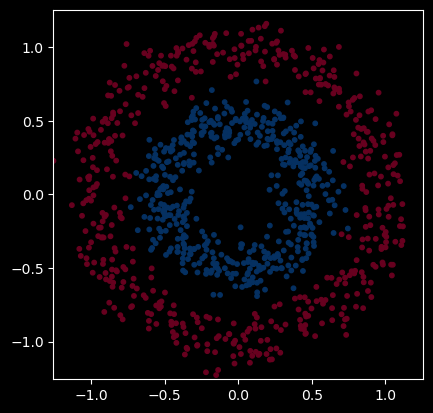

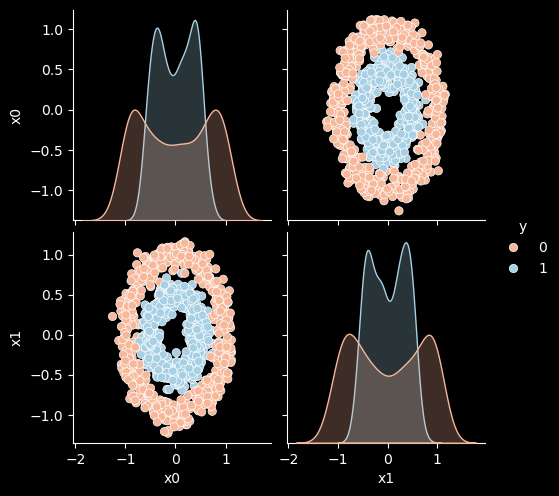

In [3]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 3

if   choice == 0:
    X, y = make_blobs(
        n_samples=n_samples,
        n_features=2,
        centers=2,
        cluster_std=5,
        random_state=10
    )
elif choice == 1:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        n_classes=3,
        random_state=41
    )
elif choice == 2:
    X, y = make_moons(
        n_samples=n_samples,
        noise=0.2,
        random_state=42
    )
elif choice == 3:
    X, y = make_circles(
        n_samples=n_samples,
        noise=0.1,
        factor=0.5,
        random_state=42
    )

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

n_classes = np.unique(y).shape[0]

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap='RdBu')
plt.xlim(-MAX, MAX)
plt.ylim(-MAX, MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame({'x0': X[:,0], 'x1': X[:,1], 'y': y})
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Modeling

### 3.1 Train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

### 3.2 Build the network

The architecture is identical to the regression network — `Dense` layers with ReLU — until the last
layer, where two things change together.

**Softmax output.** The final layer has one unit per class, and `softmax` converts those raw scores
into a probability distribution:

$$\hat{p}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \qquad k = 1, \ldots, K$$

Every output is in $(0,1)$ and they sum to 1 by construction. Compare with the regression case,
where the last layer was a single **linear** unit precisely so its output could be any real number.

**Cross-entropy loss.** `sparse_categorical_crossentropy` is the quantity built from scratch in
`U1-6_Classify-2_Entropy`. For a single example with true class $y$, a one-hot truth collapses the
cross-entropy sum to one term:

$$\mathcal{L} = -\log \hat{p}_y$$

and averaged over $N$ examples,
$\mathcal{L} = -\frac{1}{N}\sum_i \log \hat{p}^{(i)}_{y_i}$. The **sparse** variant simply takes
integer labels directly instead of requiring one-hot vectors; the quantity computed is identical.

Why not MSE on the probabilities? Because cross-entropy's penalty for a confidently wrong prediction
grows without bound as $\hat{p}_y \to 0$, while squared error saturates at 1. Confident mistakes are
the ones worth punishing hardest.

**`EarlyStopping`** watches validation loss and restores the best weights once it stops improving —
automating the "stop at the peak of the test curve" rule from `U1-3_Regression-2_Overfitting`.

The diagram printed after `summary()` shows the untrained network: weights are small random values,
so every edge is thin.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

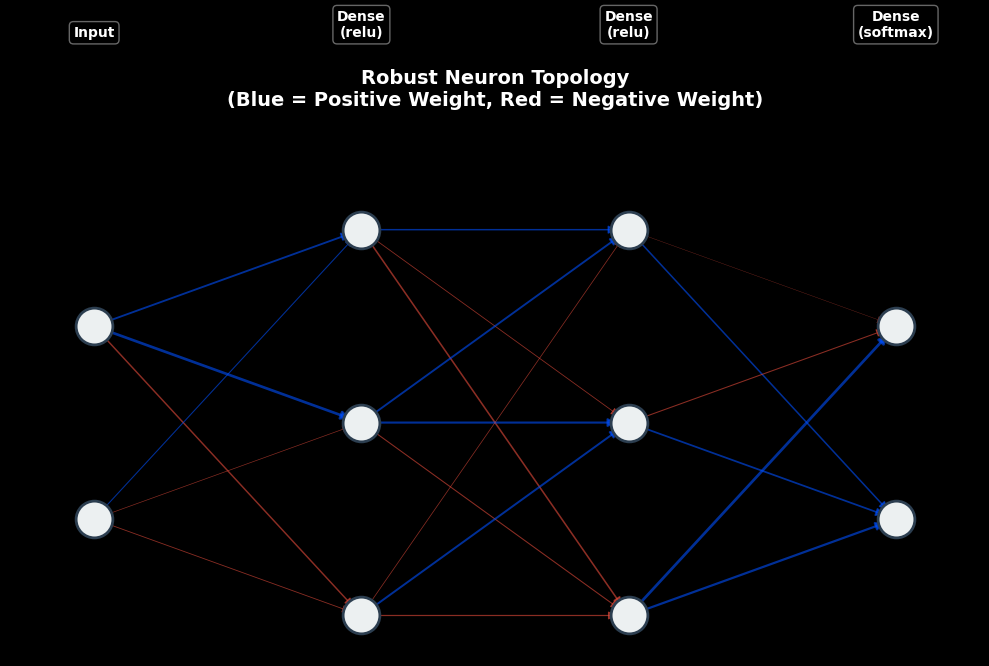

In [5]:
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(3, activation='relu'),
    Dense(3, activation='relu'),
    Dense(n_classes, activation='softmax'),
])

optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

model.summary()

plot_robust_neuron_network(model)

### 3.3 Train

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/200


 1/13 ━━━━━━━━━━━━━━━━━━━━ 7s 607ms/step - accuracy: 0.4844 - loss: 0.7849

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3787 - loss: 0.7519 - val_accuracy: 0.3500 - val_loss: 0.7215


Epoch 2/200


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3281 - loss: 0.7260

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8906 - loss: 0.3072

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8438 - loss: 0.3794 - val_accuracy: 0.8750 - val_loss: 0.3195


Epoch 200/200


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7969 - loss: 0.4597

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8450 - loss: 0.3799 - val_accuracy: 0.8750 - val_loss: 0.3249


### 3.4 The trained weights

The same diagram after fitting. Compare against the untrained version above — some paths have
thickened into the dominant route from input to output, others have collapsed toward zero.

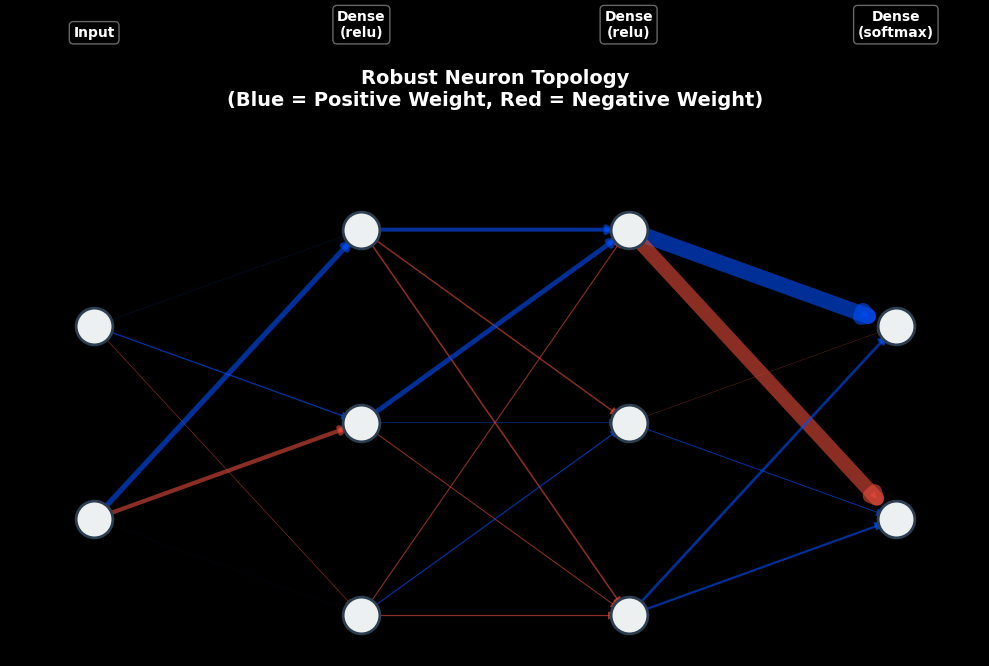

In [7]:
plot_robust_neuron_network(model)

### 3.5 Reading the output

A classifier's `predict` returns the **probability vector**, not a label — one row per sample, one
column per class, each row summing to 1.

In [8]:
# predict() returns class probabilities (softmax output)
model.predict(X_test)[:5, :]

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([[9.9956220e-01, 4.3781596e-04],
       [2.2716314e-01, 7.7283686e-01],
       [8.3752328e-01, 1.6247675e-01],
       [2.2716314e-01, 7.7283686e-01],
       [9.8035884e-01, 1.9641144e-02]], dtype=float32)

`argmax` along the class axis converts those probabilities into predicted labels. Note that this
throws away the confidence information, which is exactly what the entropy map in the next section
puts back.

In [9]:
# argmax across class axis gives the predicted class label
y_test_prob = model.predict(X_test)
y_test_pred = y_test_prob.argmax(axis=1)
y_test_pred[:5]

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([0, 1, 0, 1, 0])

### 3.6 Evaluate

Loss and accuracy curves, a confusion matrix, the decision regions, the entropy map, and a
classification report — all the diagnostics at once.

Read the entropy panel against the region panel: the uncertain band should trace the boundary. Its
maximum is $\log_2 K$, which is why the colourbar ticks are set from that value.

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


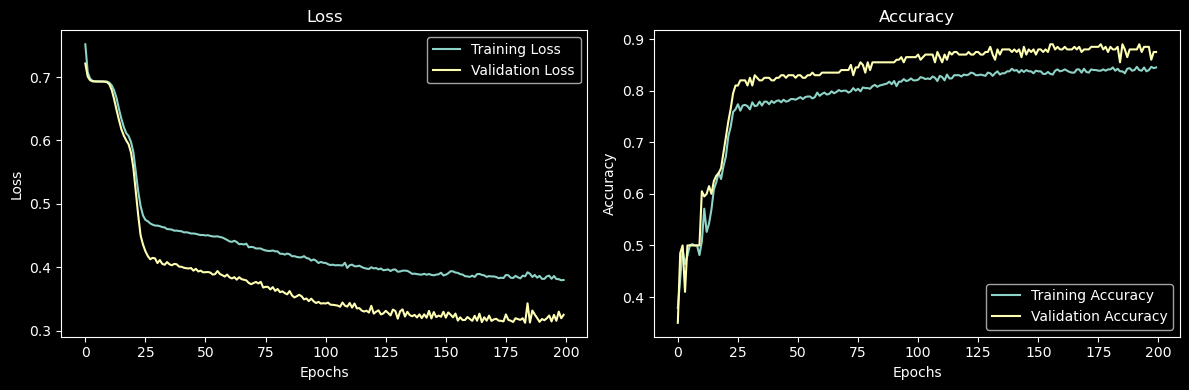

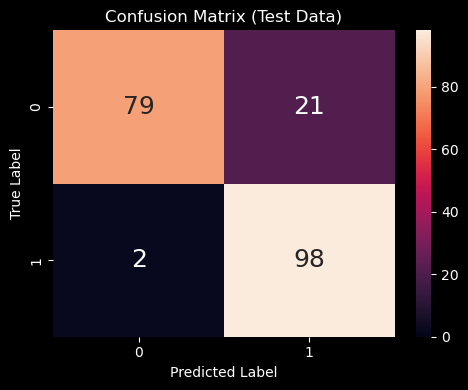

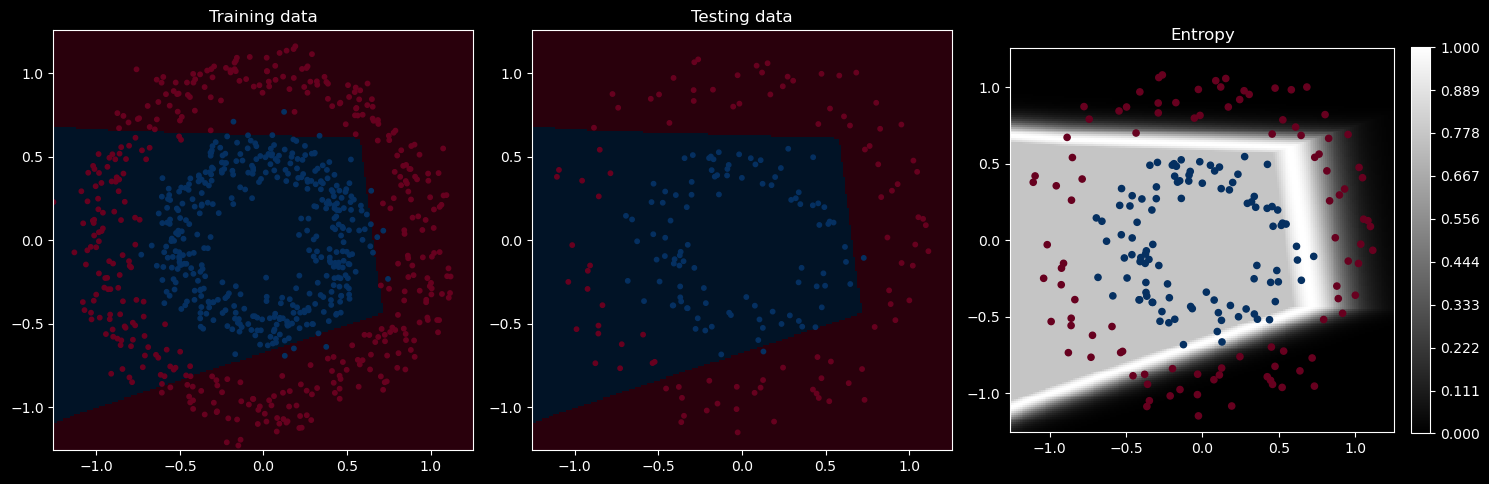

              precision    recall  f1-score   support

           0       0.98      0.79      0.87       100
           1       0.82      0.98      0.89       100

    accuracy                           0.89       200
   macro avg       0.90      0.89      0.88       200
weighted avg       0.90      0.89      0.88       200



In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_train_pred = model.predict(X_train).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, vmin=0, annot_kws={'size': 18})
ax.set_title('Confusion Matrix (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

B, S = visualize_regions_keras(model, MAX, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
extent = [-MAX, MAX, -MAX, MAX]
cmap = 'RdBu'

axes[0].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap)
axes[0].set_aspect('equal')
axes[0].set_title('Training data')

axes[1].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap)
axes[1].set_aspect('equal')
axes[1].set_title('Testing data')

im = axes[2].imshow(S, interpolation='none', extent=extent, cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap)
axes[2].set_aspect('equal')
axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(n_classes, 2), 10))

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred))

## 4. The course helper: `train_and_evaluate`

The cell above fit the model, plotted the loss/accuracy curves, and drew a confusion matrix - all by hand. That exact pattern lives in the shared course module `msds565_helpers.py` at the repository root (notebooks sit two folders below the root, so `'../..'` points back to it). Later Keras notebooks call the helper instead of re-writing the loop - and now you know exactly what it does internally.

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


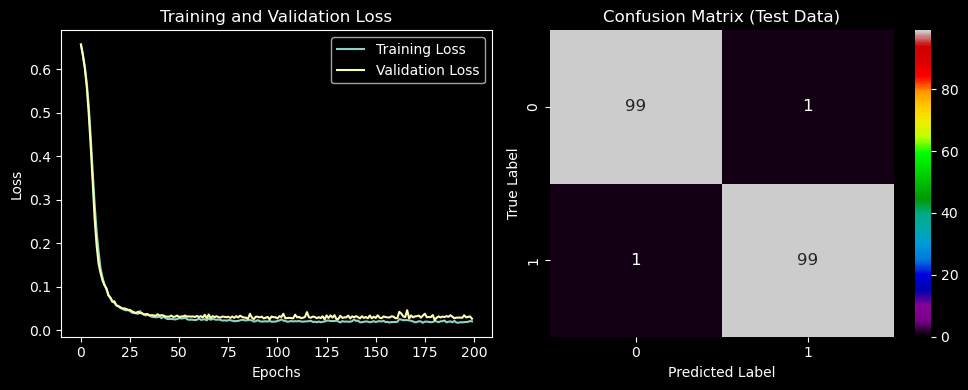

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [11]:
# Shared course helpers (msds565_helpers.py lives in the repo root).
import sys
sys.path.append('../..')
import msds565_helpers as helpers

# A fresh copy of the same architecture, trained and evaluated in one call.
model2 = Sequential([
    Input(shape=X.shape[1:]),
    Dense(3, activation='relu'),
    Dense(3, activation='relu'),
    Dense(n_classes, activation='softmax'),
])
model2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2, history2 = helpers.train_and_evaluate(
    model2, X_train, y_train, X_test, y_test,
    epochs=200, batch_size=64, verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=100,
                             restore_best_weights=True)]
)

## 5. Animate

We train one epoch at a time and capture the decision boundary grid and the network weights at each step, then assemble the frames into an animated GIF. The model here is a fresh variant that adds `BatchNormalization` between the dense layers.

The model here differs from the one above: it adds `BatchNormalization` between each linear
transform and its activation, which stabilizes training enough that the boundary moves smoothly
across frames rather than jumping.

In [12]:
from tqdm import tqdm
import matplotlib.animation as animation

from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam

model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(5),
    BatchNormalization(),
    Activation('relu'),
    Dense(5),
    BatchNormalization(),
    Activation('relu'),
    Dense(5),
    BatchNormalization(),
    Activation('relu'),
    Dense(n_classes, activation='softmax'),
])

optimizer = Adam(learning_rate=0.002)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (588.00 B)

 Trainable params: 117 (468.00 B)

 Non-trainable params: 30 (120.00 B)

In [13]:
nGrid = 200
a1 = np.linspace(-MAX, MAX, nGrid)
a2 = np.linspace(-MAX, MAX, nGrid)

A1, A2 = np.meshgrid(a1, a2)
A1 = A1.flatten()
A2 = A2.flatten()
A = np.vstack((A1, A2)).T

extent = [-MAX, MAX, -MAX, MAX]

  0%|                     | 0/150 [00:00<?, ?it/s]

  1%|             | 1/150 [00:02<06:30,  2.62s/it]

  1%|▏            | 2/150 [00:03<04:13,  1.71s/it]

  2%|▎            | 3/150 [00:04<03:30,  1.43s/it]

  3%|▎            | 4/150 [00:05<03:10,  1.31s/it]

...

 98%|██████████▊| 147/150 [02:44<00:03,  1.10s/it]

 99%|██████████▊| 148/150 [02:45<00:02,  1.11s/it]

 99%|██████████▉| 149/150 [02:46<00:01,  1.11s/it]

100%|███████████| 150/150 [02:48<00:00,  1.11s/it]

100%|███████████| 150/150 [02:48<00:00,  1.12s/it]

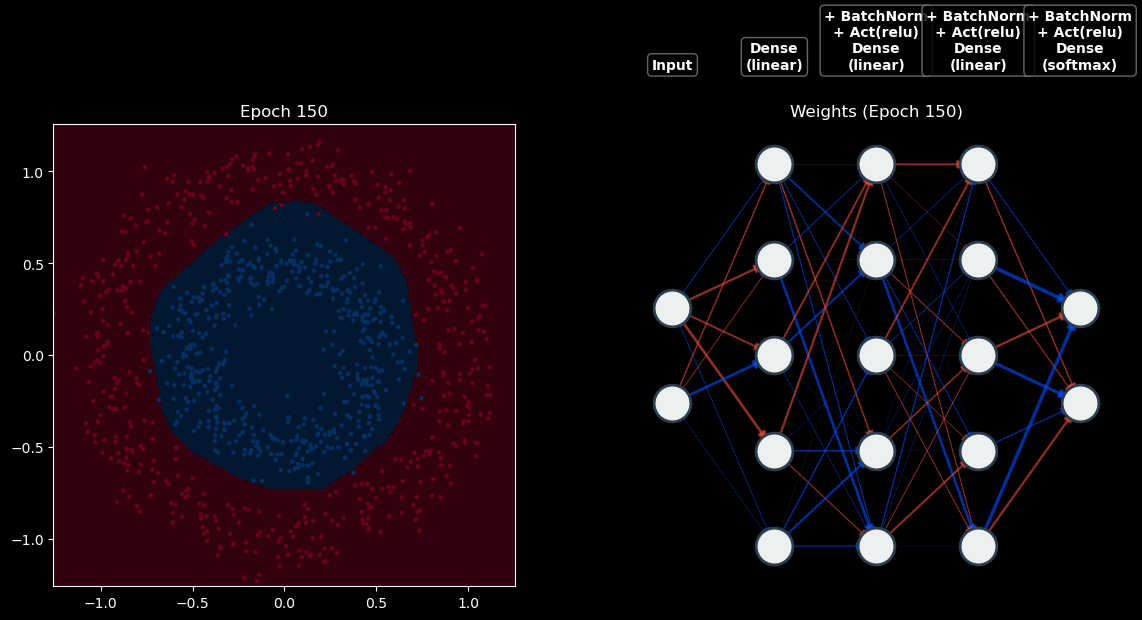

done


In [14]:
def animate(model, epochs, X_train, y_train, X_test, y_test, A, nGrid,
            filename='classification_training.gif'):
    cmap = 'RdBu'
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    predicted_frames = []
    weight_snapshots = []

    for i in tqdm(range(epochs), ncols=50):
        model.fit(X_train, y_train, epochs=1, batch_size=128,
                  validation_data=(X_test, y_test), verbose=0)
        B = model.predict(A, verbose=0).argmax(axis=1).reshape(nGrid, nGrid)
        predicted_frames.append(np.flipud(B))
        weight_snapshots.append(_get_model_graph_data(model))

    # Left subplot: decision boundary
    axes[0].scatter(X[:, 0], X[:, 1], c=y, s=5, cmap=cmap, zorder=2)
    region_plot = axes[0].imshow(predicted_frames[0], animated=True, cmap=cmap,
                                  alpha=0.5, extent=extent)
    axes[0].set_aspect('equal')
    axes[0].set_title('Epoch 1')

    # Right subplot: network weights (initial draw)
    _draw_network_on_ax(*weight_snapshots[0], axes[1])
    axes[1].set_title('Weights (Epoch 1)')

    def update(frame):
        region_plot.set_data(predicted_frames[frame])
        axes[0].set_title(f'Epoch {frame + 1}')
        axes[1].clear()
        _draw_network_on_ax(*weight_snapshots[frame], axes[1])
        axes[1].set_title(f'Weights (Epoch {frame + 1})')
        return region_plot,

    ani = animation.FuncAnimation(fig, update, frames=len(predicted_frames),
                                  interval=50, blit=False)
    ani.save(filename, writer='pillow', fps=5)
    plt.show()
    return ani


epochs = 150

animate(model, epochs, X_train, y_train, X_test, y_test, A, nGrid,
        filename='classification_training.gif')

print('done')

![classification training animation](classification_training.gif)

## 6. Review

- **A classifier network is a regression network with a different ending.** Hidden layers are
  unchanged; the output becomes one softmax unit per class.
- **Softmax produces a distribution**: $\hat{p}_k = e^{z_k}/\sum_j e^{z_j}$, positive and summing to
  1 — unlike the single linear output used for regression.
- **Cross-entropy is the matching loss**, reducing to $-\log \hat{p}_y$ for a one-hot truth. It
  punishes confident errors without bound, where squared error saturates.
- **`sparse_categorical_crossentropy` differs from `categorical_crossentropy` only in label format**,
  integer versus one-hot; the computed quantity is the same.
- **`predict` returns probabilities; `argmax` gives labels** — and discards the confidence that the
  entropy map then visualizes.
- **The animation shows the boundary and the weights moving together**, which is the clearest
  available picture of what training actually does.